# Data Exploration: EPC and Property Price Datasets

## Project Overview

This notebook explores the EPC (Energy Performance Certificate) and Property Price (PP) datasets to understand their structure, quality, and prepare for building a property price prediction model.

### Why This Analysis Matters

- **Assess data quality**: Identify missing values, outliers, and inconsistencies
- **Understand distributions**: See how the target variable (price) and features are distributed
- **Check feasibility**: Confirm the datasets can be merged
- **Inform decisions**: Guide the data cleaning and feature engineering ideas

### Datasets Used

1. **EPC Dataset**: Energy Performance Certificates from UK Department for Levelling Up, Housing and Communities
   - Contains detailed energy efficiency and property characteristics
   - Includes 93 columns with information about building structure, energy ratings, and location
   
2. **Property Price Dataset**: HM Land Registry Price Paid Data
   - Contains actual transaction prices for properties sold in the UK
   - Includes transaction details, property types, and location information

### Research Question

**Can we accurately predict UK property prices using energy performance and structural characteristics?**

This is a **regression problem** where the aim is to predict a continuous value (property price) based on multiple features.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load the Data

Loading one year (2024) as a sample to:
- Quickly understand the data structure without overwhelming memory
- Identify patterns that will apply to all years
- Test approach before scaling to 7 years of data (2018-2024)

**Note**: The full dataset contains 11.1M EPC records and 7.1M property transactions across 2018-2024. Working with a sample first allows it to iterate faster during exploration.

In [2]:
# Load EPC data for 2024
epc_2024 = pd.read_csv('../data/raw/epc-2024.csv')
print("EPC 2024 Data Loaded")
print(f"Shape: {epc_2024.shape}")
print(f"Rows: {epc_2024.shape[0]:,}, Columns: {epc_2024.shape[1]}")

EPC 2024 Data Loaded
Shape: (1647235, 93)
Rows: 1,647,235, Columns: 93


In [3]:
# Load Property Price data for 2024
pp_2024 = pd.read_csv('../data/raw/pp-2024.csv', header=None)

# The PP data doesn't have column headers, so they need to be added Based on the Land Registry specification
pp_columns = [
    'transaction_id', 'price', 'date', 'postcode', 'property_type',
    'old_new', 'duration', 'paon', 'saon', 'street', 'locality',
    'town_city', 'district', 'county', 'ppd_category', 'record_status'
]
pp_2024.columns = pp_columns

print("Property Price 2024 Data Loaded")
print(f"Shape: {pp_2024.shape}")
print(f"Rows: {pp_2024.shape[0]:,}, Columns: {pp_2024.shape[1]}")

Property Price 2024 Data Loaded
Shape: (901959, 16)
Rows: 901,959, Columns: 16


## 2. Explore EPC Dataset

Energy Performance Certificates are mandatory for properties when sold or rented in the UK. This dataset provides:
- **Objective measurements**: Floor area, room count
- **Energy characteristics**: Ratings, efficiency scores, heating systems
- **Structural details**: Property type, age, construction materials
- **Location data**: Postcode for geographic analysis

These features are likely to work with property value compared to using price data alone.

In [4]:
# Display first few rows
epc_2024.head()

,LMK_KEY,ADDRESS1,ADDRESS2,ADDRESS3,POSTCODE,BUILDING_REFERENCE_NUMBER,CURRENT_ENERGY_RATING,POTENTIAL_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY,PROPERTY_TYPE,BUILT_FORM,INSPECTION_DATE,LOCAL_AUTHORITY,CONSTITUENCY,COUNTY,LODGEMENT_DATE,TRANSACTION_TYPE,ENVIRONMENT_IMPACT_CURRENT,ENVIRONMENT_IMPACT_POTENTIAL,ENERGY_CONSUMPTION_CURRENT,ENERGY_CONSUMPTION_POTENTIAL,CO2_EMISSIONS_CURRENT,CO2_EMISS_CURR_PER_FLOOR_AREA,CO2_EMISSIONS_POTENTIAL,LIGHTING_COST_CURRENT,LIGHTING_COST_POTENTIAL,HEATING_COST_CURRENT,HEATING_COST_POTENTIAL,HOT_WATER_COST_CURRENT,HOT_WATER_COST_POTENTIAL,TOTAL_FLOOR_AREA,ENERGY_TARIFF,MAINS_GAS_FLAG,FLOOR_LEVEL,FLAT_TOP_STOREY,FLAT_STOREY_COUNT,MAIN_HEATING_CONTROLS,MULTI_GLAZE_PROPORTION,GLAZED_TYPE,GLAZED_AREA,EXTENSION_COUNT,NUMBER_HABITABLE_ROOMS,NUMBER_HEATED_ROOMS,LOW_ENERGY_LIGHTING,NUMBER_OPEN_FIREPLACES,HOTWATER_DESCRIPTION,HOT_WATER_ENERGY_EFF,HOT_WATER_ENV_EFF,FLOOR_DESCRIPTION,FLOOR_ENERGY_EFF,FLOOR_ENV_EFF,WINDOWS_DESCRIPTION,WINDOWS_ENERGY_EFF,WINDOWS_ENV_EFF,WALLS_DESCRIPTION,WALLS_ENERGY_EFF,WALLS_ENV_EFF,SECONDHEAT_DESCRIPTION,SHEATING_ENERGY_EFF,SHEATING_ENV_EFF,ROOF_DESCRIPTION,ROOF_ENERGY_EFF,ROOF_ENV_EFF,MAINHEAT_DESCRIPTION,MAINHEAT_ENERGY_EFF,MAINHEAT_ENV_EFF,MAINHEATCONT_DESCRIPTION,MAINHEATC_ENERGY_EFF,MAINHEATC_ENV_EFF,LIGHTING_DESCRIPTION,LIGHTING_ENERGY_EFF,LIGHTING_ENV_EFF,MAIN_FUEL,WIND_TURBINE_COUNT,HEAT_LOSS_CORRIDOR,UNHEATED_CORRIDOR_LENGTH,FLOOR_HEIGHT,PHOTO_SUPPLY,SOLAR_WATER_HEATING_FLAG,MECHANICAL_VENTILATION,ADDRESS,LOCAL_AUTHORITY_LABEL,CONSTITUENCY_LABEL,POSTTOWN,CONSTRUCTION_AGE_BAND,LODGEMENT_DATETIME,TENURE,FIXED_LIGHTING_OUTLETS_COUNT,LOW_ENERGY_FIXED_LIGHT_COUNT,UPRN,UPRN_SOURCE,REPORT_TYPE
0,035b0dbdfab799579ec9d25dc70725cbea2aba0442fad7...,3 The Mews,Earlsleigh 29-35,Groby Road,WA14 2BQ,10005886484,C,B,70,83,House,End-Terrace,2024-04-24,E08000009,E14000532,NaN,2024-04-25,rental,67,80,187,110,3.7,33,2.2,258,136,996,962,265,162,111.0,Single,Y,NaN,NaN,NaN,NaN,100,"double glazing, unknown install date",Normal,1.0,4.0,4.0,11,0,From main system,Good,Good,"Solid, no insulation (assumed)",NaN,NaN,Fully double glazed,Average,Average,"Cavity wall, as built, insulated (assumed)",Good,Good,NaN,NaN,NaN,"Pitched, 100 mm loft insulation",Average,Average,"Boiler and radiators, mains gas",Good,Good,Programmer and room thermostat,Average,Average,Low energy lighting in 11% of fixed outlets,Poor,Poor,mains gas (not community),0,NaN,NaN,2.51,0.0,N,natural,"3 The Mews, Earlsleigh 29-35, Groby Road",Trafford,Altrincham and Sale West,ALTRINCHAM,England and Wales: 1983-1990,2024-04-25 15:51:22,Rented (private),19,NaN,2.000003e+11,Energy Assessor,100
1,035b2acd23f67c89b43fc1396458b574a0acedd1fc7349...,8 Mill Street,NaN,NaN,SO50 4HF,10005931072,C,B,72,88,House,Mid-Terrace,2024-04-03,E07000086,E14000685,Hampshire,2024-04-05,marketed sale,71,87,184,56,2.1,32,0.7,92,92,653,558,173,114,66.0,Single,Y,NaN,NaN,NaN,NaN,100,"double glazing, unknown install date",Normal,1.0,4.0,4.0,100,0,From main system,Good,Good,"Suspended, no insulation (assumed)",NaN,NaN,Fully double glazed,Average,Average,"Cavity wall, as built, no insulation (assumed)",Poor,Poor,NaN,NaN,NaN,"Pitched, 200 mm loft insulation",Good,Good,"Boiler and radiators, mains gas",Good,Good,"Programmer, room thermostat and TRVs",Good,Good,Low energy lighting in all fixed outlets,Very Good,Very Good,mains gas (not community),0,NaN,NaN,2.35,0.0,N,natural,8 Mill Street,Eastleigh,Eastleigh,EASTLEIGH,England and Wales: 1900-1929,2024-04-05 16:01:08,Owner-occupied,10,NaN,1.000603e+11,Energy Assessor,100
2,035b802cc1e1cf605e79942fcb612ae342b379184f2f7b...,1 Mount Noddy,Cuckfield Road,Ansty,RH17 5AG,10005835512,E,D,44,68,House,Detached,2024-04-12,E07000228,E14000817,West Sussex,2024-04-16,marketed sale,38,58,229,123,9.9,60,5.8,233,171,1906,1346,266,160,165.0,Unknown,Y,NaN,NaN,NaN,NaN,100,"double glazing, unknown install date",Normal,1.0,7.0,7.0,64,0,From main system,Average,Average,"Solid, no insulation (assumed)",NaN,NaN

In [5]:
# Get basic information about the dataset
epc_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1647235 entries, 0 to 1647234
Data columns (total 93 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   LMK_KEY                        1647235 non-null  object 
 1   ADDRESS1                       1647230 non-null  object 
 2   ADDRESS2                       844666 non-null   object 
 3   ADDRESS3                       233575 non-null   object 
 4   POSTCODE                       1647235 non-null  object 
 5   BUILDING_REFERENCE_NUMBER      1647235 non-null  int64  
 6   CURRENT_ENERGY_RATING          1647235 non-null  object 
 7   POTENTIAL_ENERGY_RATING        1647235 non-null  object 
 8   CURRENT_ENERGY_EFFICIENCY      1647235 non-null  int64  
 9   POTENTIAL_ENERGY_EFFICIENCY    1647235 non-null  int64  
 10  PROPERTY_TYPE                  1647235 non-null  object 
 11  BUILT_FORM                     1646810 non-null  object 
 12  INSPECTION_DAT

In [6]:
# Check data types of key columns
print("Data Types of Key EPC Columns:")
key_epc_cols = [
    'POSTCODE', 'CURRENT_ENERGY_RATING', 'CURRENT_ENERGY_EFFICIENCY',
    'PROPERTY_TYPE', 'BUILT_FORM', 'TOTAL_FLOOR_AREA', 'CONSTRUCTION_AGE_BAND',
    'NUMBER_HABITABLE_ROOMS', 'TENURE'
]
print(epc_2024[key_epc_cols].dtypes)

Data Types of Key EPC Columns:
POSTCODE                      object
CURRENT_ENERGY_RATING         object
CURRENT_ENERGY_EFFICIENCY      int64
PROPERTY_TYPE                 object
BUILT_FORM                    object
TOTAL_FLOOR_AREA             float64
CONSTRUCTION_AGE_BAND         object
NUMBER_HABITABLE_ROOMS       float64
TENURE                        object
dtype: object


In [7]:
# Check for missing values in key columns
print("Missing Values in EPC Dataset:")
missing_epc = epc_2024[key_epc_cols].isnull().sum()
missing_pct = (missing_epc / len(epc_2024)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_epc,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

Missing Values in EPC Dataset:
                        Missing Count  Percentage
NUMBER_HABITABLE_ROOMS         218512   13.265381
BUILT_FORM                        425    0.025801


In [8]:
# Basic statistics for numeric columns
print("Basic Statistics for Numeric EPC Columns:")
epc_2024[['CURRENT_ENERGY_EFFICIENCY', 'TOTAL_FLOOR_AREA', 'NUMBER_HABITABLE_ROOMS']].describe()

Basic Statistics for Numeric EPC Columns:


,CURRENT_ENERGY_EFFICIENCY,TOTAL_FLOOR_AREA,NUMBER_HABITABLE_ROOMS
count,1.647235e+06,1.647235e+06,1.428723e+06
mean,6.945446e+01,8.696331e+01,4.166610e+00
std,1.197728e+01,5.248962e+01,1.752666e+00
min,1.000000e+00,0.000000e+00,1.000000e+00
25%,6.400000e+01,6.000000e+01,3.000000e+00
50%,7.000000e+01,7.700000e+01,4.000000e+00
75%,7.600000e+01,9.800000e+01,5.000000e+00
max,2.110000e+02,6.802000e+03,9.900000e+01


### Key Finding: Missing Values

- `NUMBER_HABITABLE_ROOMS`: 13.3% missing - This is significant but manageable. May need to impute these values or use the property type to estimate room counts.
- `BUILT_FORM`: Only 0.03% missing - Excellent quality, minimal impact.

Property Type Distribution in EPC:
PROPERTY_TYPE
House         998086
Flat          473043
Bungalow      135894
Maisonette     39167
Park home       1045
Name: count, dtype: int64


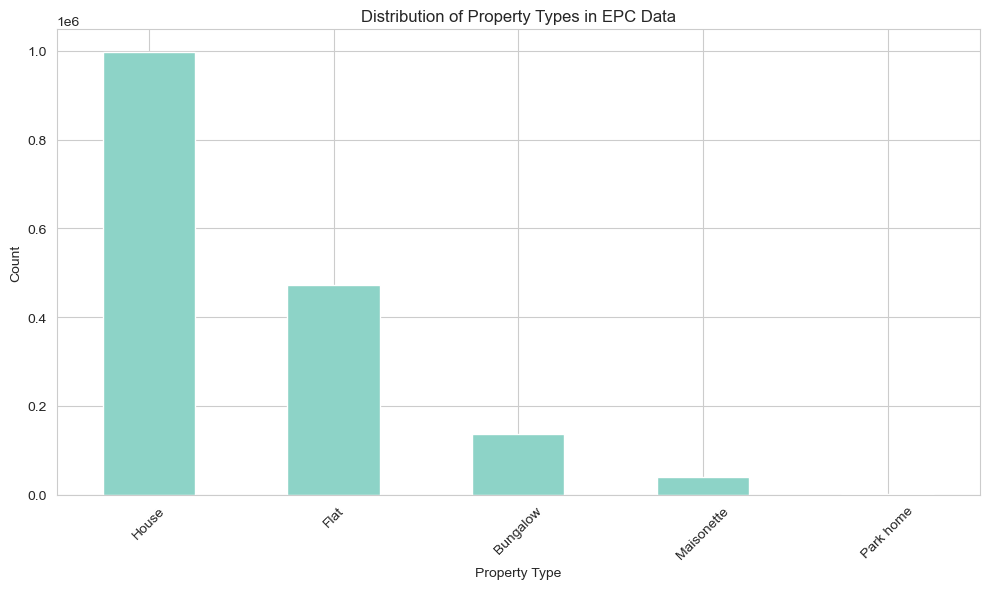

In [9]:
# Distribution of property types
print("Property Type Distribution in EPC:")
print(epc_2024['PROPERTY_TYPE'].value_counts())

# Visualize property type distribution
plt.figure(figsize=(10, 6))
epc_2024['PROPERTY_TYPE'].value_counts().plot(kind='bar')
plt.title('Distribution of Property Types in EPC Data')
plt.xlabel('Property Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Energy Rating Distribution:
CURRENT_ENERGY_RATING
A     28483
B    237090
C    731012
D    509873
E    108140
F     24327
G      8310
Name: count, dtype: int64


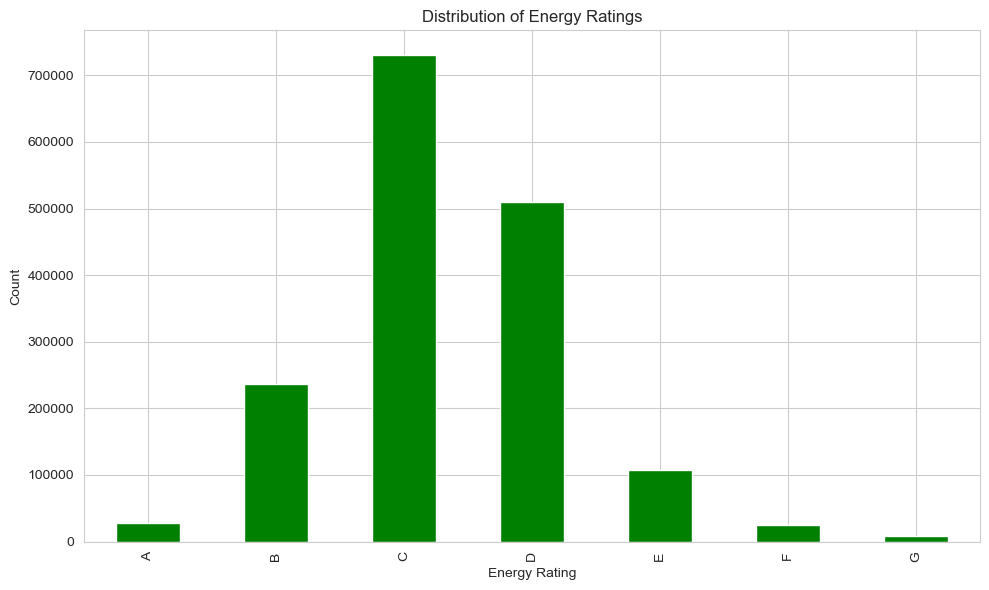

In [10]:
# Distribution of energy ratings
print("Energy Rating Distribution:")
print(epc_2024['CURRENT_ENERGY_RATING'].value_counts().sort_index())

# Visualize energy rating distribution
plt.figure(figsize=(10, 6))
epc_2024['CURRENT_ENERGY_RATING'].value_counts().sort_index().plot(kind='bar', color='green')
plt.title('Distribution of Energy Ratings')
plt.xlabel('Energy Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

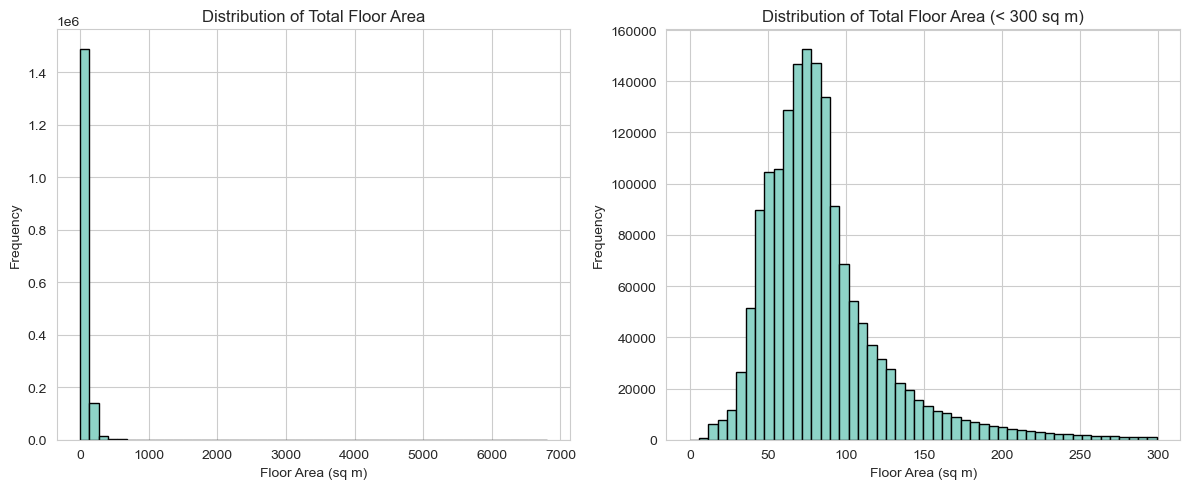

In [11]:
# Distribution of floor area
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
epc_2024['TOTAL_FLOOR_AREA'].hist(bins=50, edgecolor='black')
plt.title('Distribution of Total Floor Area')
plt.xlabel('Floor Area (sq m)')
plt.ylabel('Frequency')

# Remove outliers for better visualization
plt.subplot(1, 2, 2)
epc_2024[epc_2024['TOTAL_FLOOR_AREA'] < 300]['TOTAL_FLOOR_AREA'].hist(bins=50, edgecolor='black')
plt.title('Distribution of Total Floor Area (< 300 sq m)')
plt.xlabel('Floor Area (sq m)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Key Finding: EPC Numeric Distributions

**Floor Area:**
- Mean: 87 sqm, Median: 77 sqm
- Range: 0-6,802 sqm (extreme outliers present)
- **Concern**: The minimum of 0 sqm is clearly an error. The maximum of 6,802 sqm suggests commercial properties or data errors.
- **Action needed**: Filter to reasonable residential ranges (e.g., 20-500 sqm) during cleaning.

**Energy Efficiency:**
- Mean: 69.5, Median: 70
- Range: 1-211

**Habitable Rooms:**
- Mean: 4.2, Median: 4
- Max: 99 rooms
- **Concern**: 99 rooms suggests data quality issues or commercial properties. to be caped during cleaning.

## 3. Explore Property Price Dataset

The HM Land Registry Price Paid dataset is the gold standard for UK property prices:
- **Official source**: Legal requirement to register property sales
- **Comprehensive**: Covers nearly all residential transactions
- **Reliable**: Based on actual completed sales, not asking prices
- **Transparent**: Publicly available government data

In [12]:
# Display first few rows
pp_2024.head()

,transaction_id,price,date,postcode,property_type,old_new,duration,paon,saon,street,locality,town_city,district,county,ppd_category,record_status
0,{2131FCF5-B031-86E8-E063-4804A8C0372B},320000,2024-07-26 00:00,MK40 3SG,T,N,F,38,NaN,GEORGE STREET,NaN,BEDFORD,BEDFORD,BEDFORD,A,A
1,{2131FCF5-B034-86E8-E063-4804A8C0372B},300000,2024-02-15 00:00,MK43 9GH,S,N,F,12,NaN,BRICK CRESCENT,STEWARTBY,BEDFORD,BEDFORD,BEDFORD,A,A
2,{2131FCF5-B036-86E8-E063-4804A8C0372B},470000,2024-08-21 00:00,MK45 2BF,S,N,F,21,NaN,COLTSFOOT CORNER,AMPTHILL,BEDFORD,CENTRAL BEDFORDSHIRE,CENTRAL BEDFORDSHIRE,A,A
3,{2131FCF5-B037-86E8-E063-4804A8C0372B},527500,2024-07-29 00:00,MK43 0YX,D,N,L,1,NaN,FALLOWS CRESCENT,CRANFIELD,BEDFORD,CENTRAL BEDFORDSHIRE,CENTRAL BEDFORDSHIRE,A,A
4,{2131FCF5-B038-86E8-E063-4804A8C0372B},351000,2024-07-17 00:00,LU3 3AR,T,N,F,320,NaN,SUNDON PARK ROAD,NaN,LUTON,LUTON,LUTON,A,A


In [13]:
# Get basic information
pp_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 901959 entries, 0 to 901958
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   transaction_id  901959 non-null  object
 1   price           901959 non-null  int64 
 2   date            901959 non-null  object
 3   postcode        899401 non-null  object
 4   property_type   901959 non-null  object
 5   old_new         901959 non-null  object
 6   duration        901959 non-null  object
 7   paon            901959 non-null  object
 8   saon            115553 non-null  object
 9   street          887567 non-null  object
 10  locality        342266 non-null  object
 11  town_city       901959 non-null  object
 12  district        901959 non-null  object
 13  county          901959 non-null  object
 14  ppd_category    901959 non-null  object
 15  record_status   901959 non-null  object
dtypes: int64(1), object(15)
memory usage: 110.1+ MB


In [14]:
# Check for missing values
print("Missing Values in Property Price Dataset:")
missing_pp = pp_2024.isnull().sum()
missing_pct_pp = (missing_pp / len(pp_2024)) * 100
missing_pp_df = pd.DataFrame({
    'Missing Count': missing_pp,
    'Percentage': missing_pct_pp
})
print(missing_pp_df[missing_pp_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

Missing Values in Property Price Dataset:
          Missing Count  Percentage
saon             786406   87.188664
locality         559693   62.053042
street            14392    1.595638
postcode           2558    0.283605


In [15]:
# Check for missing values
print("Missing Values in Property Price Dataset:")
missing_pp = pp_2024.isnull().sum()
missing_pct_pp = (missing_pp / len(pp_2024)) * 100
missing_pp_df = pd.DataFrame({
    'Missing Count': missing_pp,
    'Percentage': missing_pct_pp
})
print(missing_pp_df[missing_pp_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

Missing Values in Property Price Dataset:
          Missing Count  Percentage
saon             786406   87.188664
locality         559693   62.053042
street            14392    1.595638
postcode           2558    0.283605


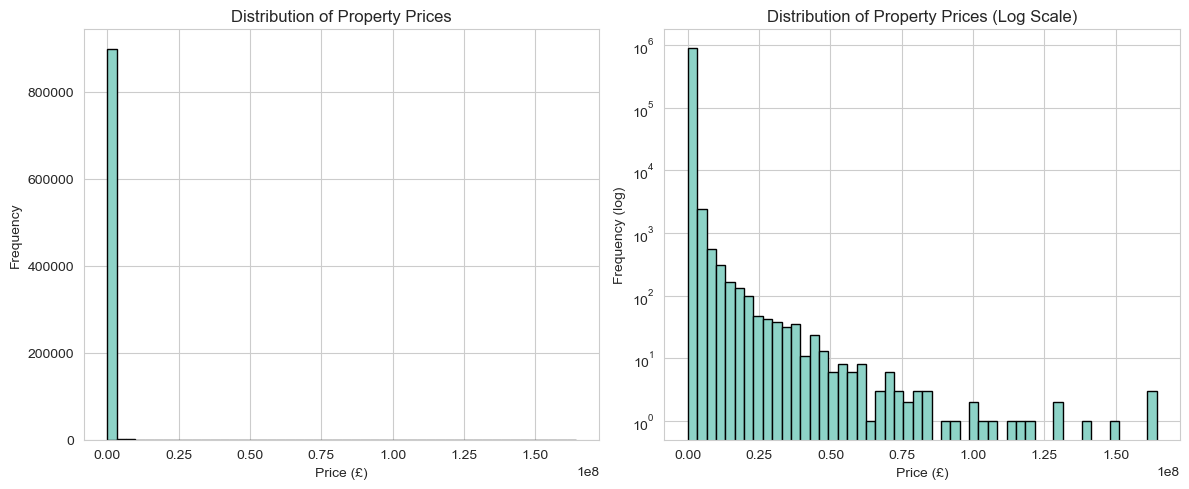

In [16]:
# Distribution of property prices
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
pp_2024['price'].hist(bins=50, edgecolor='black')
plt.title('Distribution of Property Prices')
plt.xlabel('Price (£)')
plt.ylabel('Frequency')

# Log scale for better visualization
plt.subplot(1, 2, 2)
pp_2024['price'].hist(bins=50, edgecolor='black', log=True)
plt.title('Distribution of Property Prices (Log Scale)')
plt.xlabel('Price (£)')
plt.ylabel('Frequency (log)')

plt.tight_layout()
plt.show()

Property Type Distribution in PP Data:
property_type
S    246172
T    245407
D    205136
F    156288
O     48956
Name: count, dtype: int64


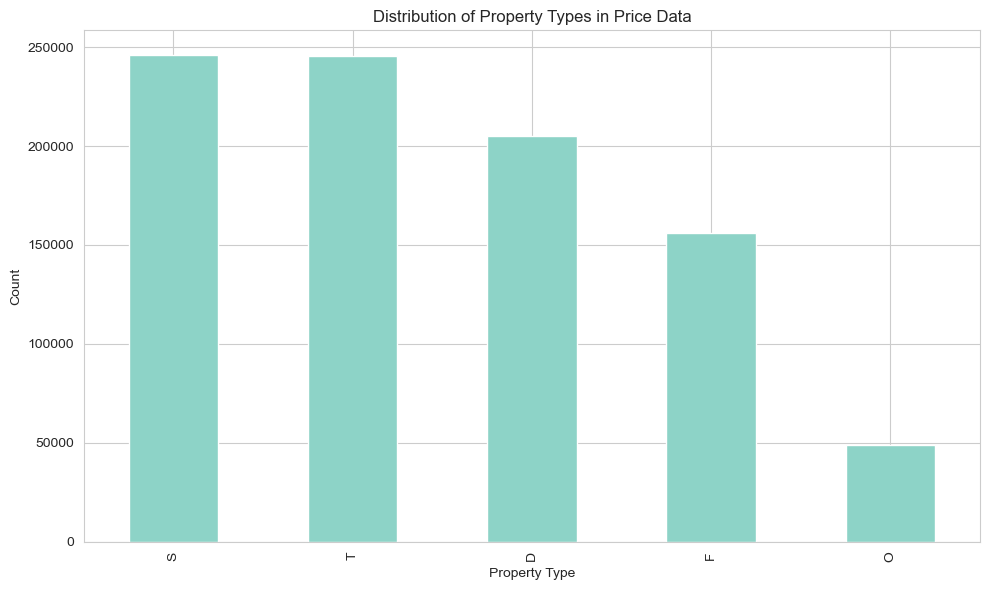

In [17]:
# Distribution of property types in price data
print("Property Type Distribution in PP Data:")
print(pp_2024['property_type'].value_counts())

# Visualize
plt.figure(figsize=(10, 6))
pp_2024['property_type'].value_counts().plot(kind='bar')
plt.title('Distribution of Property Types in Price Data')
plt.xlabel('Property Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Average Price by Property Type:
                       mean    median   count
property_type                                
D              5.057961e+05  410000.0  205136
F              3.281094e+05  235000.0  156288
O              1.057652e+06  300000.0   48956
S              3.145305e+05  262000.0  246172
T              2.910845e+05  220000.0  245407


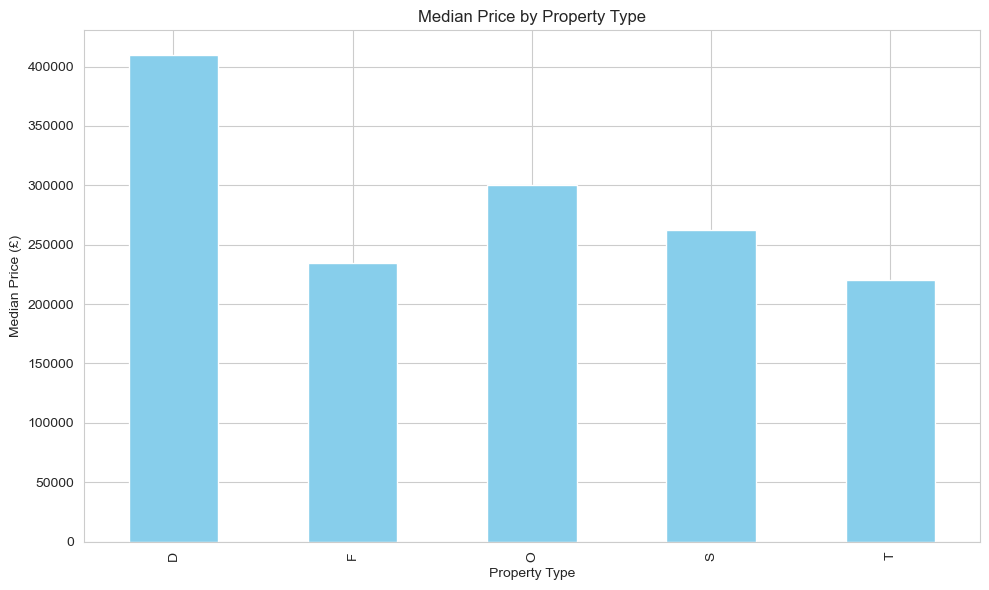

In [18]:
# Price by property type
print("Average Price by Property Type:")
price_by_type = pp_2024.groupby('property_type')['price'].agg(['mean', 'median', 'count'])
print(price_by_type)

# Visualize
plt.figure(figsize=(10, 6))
price_by_type['median'].plot(kind='bar', color='skyblue')
plt.title('Median Price by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Median Price (£)')
plt.tight_layout()
plt.show()

In [19]:
# Old vs New property distribution
print("Old vs New Property:")
print(pp_2024['old_new'].value_counts())

# Price comparison
print("\nPrice by Old/New:")
print(pp_2024.groupby('old_new')['price'].agg(['mean', 'median', 'count']))

Old vs New Property:
old_new
N    822368
Y     79591
Name: count, dtype: int64

Price by Old/New:
                  mean    median   count
old_new                                 
N        395346.803037  275000.0  822368
Y        383927.703798  330000.0   79591


In [20]:
# Duration type (Freehold vs Leasehold)
print("Duration Type:")
print(pp_2024['duration'].value_counts())

# Price comparison
print("\nPrice by Duration:")
print(pp_2024.groupby('duration')['price'].agg(['mean', 'median', 'count']))

Duration Type:
duration
F    696479
L    205480
Name: count, dtype: int64

Price by Duration:
                   mean    median   count
duration                                 
F         410850.568260  295000.0  696479
L         338373.353426  220500.0  205480


### Key Finding: Price Distribution and Outliers

- **Median**: £280,000 (typical property price)
- **Mean**: £394,339 (pulled up by expensive properties)
- **Min**: £1 (likely gift transfers or data errors)
- **Max**: £164,300,000 (luxury/commercial property or multiple units)

**The mean > median shows the distribution is right-skewed** - a small number of very expensive properties pull the average up.

**Implications for the model:**
1. **Need to filter outliers**: £1 sales aren't genuine market transactions
2. **Define reasonable range**: Focus on typical residential properties (£10K - £5M)
3. **Consider log transformation**: Might help model performance with skewed target variable
4. **Feature engineering opportunity**: Create price bands or log(price) as alternative targets

**Ethical consideration**: Extremely cheap sales might include:
- Transfers between family members
- Social housing schemes
- Repossessions

## 4. Check Temporal Coverage

Understanding the date range is important for the analysis.

In [21]:
# Convert date columns to datetime
pp_2024['date'] = pd.to_datetime(pp_2024['date'])
epc_2024['LODGEMENT_DATE'] = pd.to_datetime(epc_2024['LODGEMENT_DATE'])

print("Property Price Date Range:")
print(f"Earliest: {pp_2024['date'].min()}")
print(f"Latest: {pp_2024['date'].max()}")

print("\nEPC Lodgement Date Range:")
print(f"Earliest: {epc_2024['LODGEMENT_DATE'].min()}")
print(f"Latest: {epc_2024['LODGEMENT_DATE'].max()}")

Property Price Date Range:
Earliest: 2024-01-01 00:00:00
Latest: 2024-12-31 00:00:00

EPC Lodgement Date Range:
Earliest: 2024-01-01 00:00:00
Latest: 2024-12-31 00:00:00


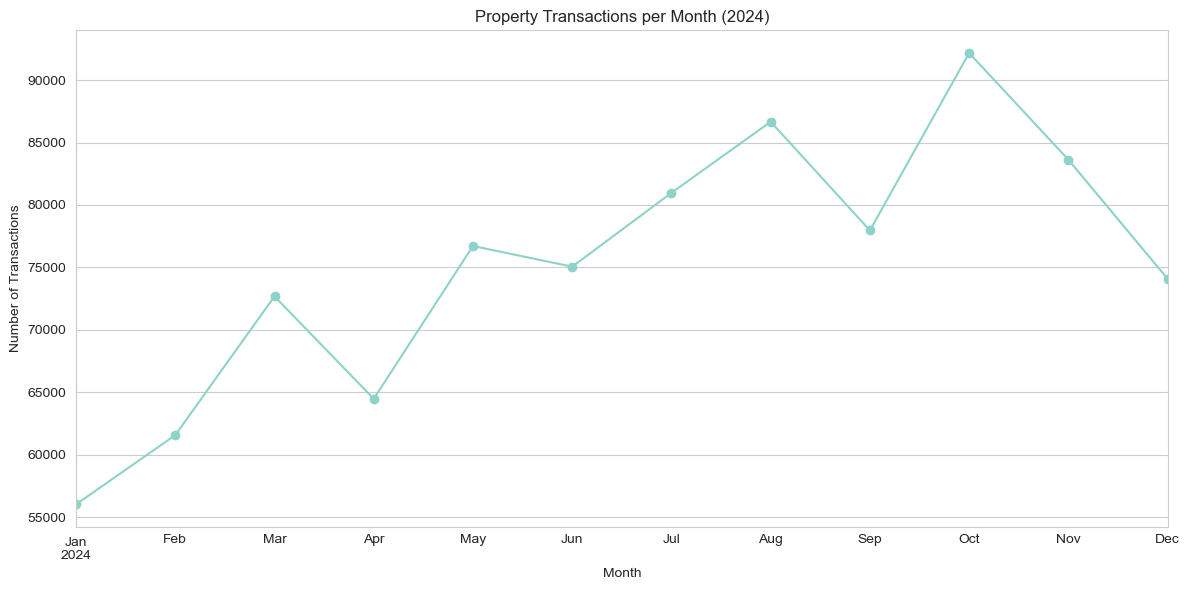

In [22]:
# Transactions over time
pp_2024['month'] = pp_2024['date'].dt.to_period('M')
monthly_counts = pp_2024.groupby('month').size()

plt.figure(figsize=(12, 6))
monthly_counts.plot(kind='line', marker='o')
plt.title('Property Transactions per Month (2024)')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Check Postcode Coverage

Understand postcode coverage since this will be key for joining EPC and PP data.

In [23]:
# Count unique postcodes in each dataset
print(f"Unique postcodes in EPC data: {epc_2024['POSTCODE'].nunique():,}")
print(f"Unique postcodes in PP data: {pp_2024['postcode'].nunique():,}")

# Check overlap
epc_postcodes = set(epc_2024['POSTCODE'].dropna())
pp_postcodes = set(pp_2024['postcode'].dropna())
common_postcodes = epc_postcodes.intersection(pp_postcodes)

print(f"\nCommon postcodes: {len(common_postcodes):,}")
print(f"Percentage of PP postcodes in EPC: {len(common_postcodes)/len(pp_postcodes)*100:.1f}%")
print(f"Percentage of EPC postcodes in PP: {len(common_postcodes)/len(epc_postcodes)*100:.1f}%")

Unique postcodes in EPC data: 665,716
Unique postcodes in PP data: 518,196

Common postcodes: 352,329
Percentage of PP postcodes in EPC: 68.0%
Percentage of EPC postcodes in PP: 52.9%


### Key Finding: Postcode Overlap

**Results:**
- 68% of property sale postcodes have matching EPC data
- This is the primary join key for merging datasets

**Interpretation:**
The 68% overlap is good because:
- Not all properties have recent EPCs (certificates last 10 years)
- Some sales might be for new builds without EPCs yet
- Very old properties might not have EPCs

**Strategy for merging:**
Use an **inner join** on postcode, accepting a loss ~32% of price records. However, in return gain rich energy and structural features for the 68% that matched.

**Trade-off accepted**: Quality over quantity. 68% of 7.1M transactions still gives ~5M training records - more than sufficient for model training.

## 6. Initial Data Quality Observations

Summary of findings from this exploration.

In [24]:
print("\n1. DATASET SIZES:")
print(f"   - EPC 2024: {len(epc_2024):,} records")
print(f"   - PP 2024: {len(pp_2024):,} records")

print("\n2. MISSING VALUES:")
print("   - EPC: Check key columns for missing data")
print("   - PP: Most address fields have missing values")

print("\n3. DATA TYPES:")
print("   - PP price data needs to be numeric")
print("   - Date columns need to be converted to datetime")
print("   - Many EPC columns are categorical")

print("\n4. POTENTIAL ISSUES:")
print("   - Need to join datasets on postcode")
print("   - May need to handle outliers in price and floor area")
print("   - Missing values need to be addressed")
print("   - Multiple EPC records per postcode possible")


1. DATASET SIZES:
   - EPC 2024: 1,647,235 records
   - PP 2024: 901,959 records

2. MISSING VALUES:
   - EPC: Check key columns for missing data
   - PP: Most address fields have missing values

3. DATA TYPES:
   - PP price data needs to be numeric
   - Date columns need to be converted to datetime
   - Many EPC columns are categorical

4. POTENTIAL ISSUES:
   - Need to join datasets on postcode
   - May need to handle outliers in price and floor area
   - Missing values need to be addressed
   - Multiple EPC records per postcode possible


## 7. Sample Data Preview

sample records to better understand the data.

In [25]:
# Sample EPC record
print("Sample EPC Record:")
sample_cols = [
    'POSTCODE', 'PROPERTY_TYPE', 'BUILT_FORM', 'CURRENT_ENERGY_RATING',
    'TOTAL_FLOOR_AREA', 'NUMBER_HABITABLE_ROOMS', 'CONSTRUCTION_AGE_BAND'
]
epc_2024[sample_cols].head(3)

Sample EPC Record:


,POSTCODE,PROPERTY_TYPE,BUILT_FORM,CURRENT_ENERGY_RATING,TOTAL_FLOOR_AREA,NUMBER_HABITABLE_ROOMS,CONSTRUCTION_AGE_BAND
0,WA14 2BQ,House,End-Terrace,C,111.0,4.0,England and Wales: 1983-1990
1,SO50 4HF,House,Mid-Terrace,C,66.0,4.0,England and Wales: 1900-1929
2,RH17 5AG,House,Detached,E,165.0,7.0,England and Wales: 1950-1966


In [26]:
# Sample PP record
print("Sample Property Price Record:")
sample_pp_cols = [
    'price', 'date', 'postcode', 'property_type', 'old_new', 'duration', 'town_city'
]
pp_2024[sample_pp_cols].head(3)

Sample Property Price Record:


,price,date,postcode,property_type,old_new,duration,town_city
0,320000,2024-07-26,MK40 3SG,T,N,F,BEDFORD
1,300000,2024-02-15,MK43 9GH,S,N,F,BEDFORD
2,470000,2024-08-21,MK45 2BF,S,N,F,BEDFORD


## Summary of Exploration Findings

### 1. Data Quality Assessment

**Strengths:**
- Large datasets: 1.6M EPC records and 900K transactions just for 2024
- Official government sources - high reliability
- Good postcode coverage for joining (68% overlap)
- Minimal missing values in key fields

**Challenges Identified:**
- Extreme outliers in price (£1 to £164M) and floor area (0 to 6,802 sqm)
- 13% missing room counts in EPC data
- One-to-many relationship between postcodes and properties

### 2. important Insights for Model Development

1. **Target Variable (Price)**: Right-skewed distribution suggests:
   - Filter to reasonable residential range (£10K-£5M)
   - Consider log transformation for model training
   - Use median-based metrics (MAE) alongside mean-based (RMSE)

2. **Feature Availability**: rich features including:
   - Structural: floor area, rooms, property type, age
   - Energy: ratings, efficiency scores
   - Location: postcode, district, county
   - Temporal: sale date, EPC lodgement date

### Reflection on Exploration Process

**What worked well:**
- Loading a single year first allowed fast iteration without memory issues
- Visualization revealed distribution patterns not obvious from statistics alone
- Checking postcode overlap early validated our merging strategy

**Challenges encountered:**
- The sheer size of the data (1.6M records) made some visualizations slow
- Understanding the Land Registry column names required external documentation
- Deciding on appropriate outlier thresholds required domain knowledge about UK property market

**Learning:**
Working with real-world government data requires careful validation. Unlike cleaned Kaggle datasets, these files have genuine data quality issues (£1 sales, 0 sqm properties) that must be handled. The trade-off between data quality and quantity is ongoing.